In [3]:
# Check if autoreload is loaded and load/reload accordingly
try:
    %reload_ext autoreload
except Exception:
    %load_ext autoreload
%autoreload 2


# Basic useful imports
from pathlib import Path
import h5py

import sys
sys.setrecursionlimit(10000)

# Data manipulation
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Clustering stuff
from itertools import cycle

# Functions for my simulations
from dyn_cond_fig_functions import *


# Locations
ws_path = Path('/home/alamson/DATA/Chromatin/')
mnt_path = Path.home() / 'projects/DATA/Chromatin/'
ceph_path = Path.home() / 'ceph/DATA/Chromatin/'

### Style settings

In [4]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 10,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    # "font.sans-serif": 'Helvetica',
    "text.usetex": False,
    'mathtext.fontset': 'cm',
    "axes.grid": True,
}
plt.style.use(graph_sty)

colors = cycle(mcolors.XKCD_COLORS.keys())

plt.rcParams['image.cmap'] = 'YlOrRd'
        

In [48]:
# Consistent settings
ss_ind = 1
end_ind = None
start_bead = 0
end_bead = None
part_min = 40

start_index = -1000

# System parameters
L_tot = 1600
L_tot_um = 16.0

# Cluster tracking parameters
cluster_similarity_threshold = .4 
nskip = 10 # Time snapshot skips for cluster finding. = 10 secs
tree_length = 30 # min length of a cluster tree in time snapshots. = 15 sec

# Diffusion time
visc = 1.0 # pN*s/um^2
b_diam = 0.01 # um
kbT = .00411 # pN*um
bead_diff = kbT / (3 * np.pi * visc * b_diam) # um^2/s
diff_time = b_diam**3*3.*np.pi*visc / (2.*kbT) # s
print(f"Diffusion time: {diff_time:.5f} s")

Diffusion time: 0.00115 s


# MSD cluster analysis

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


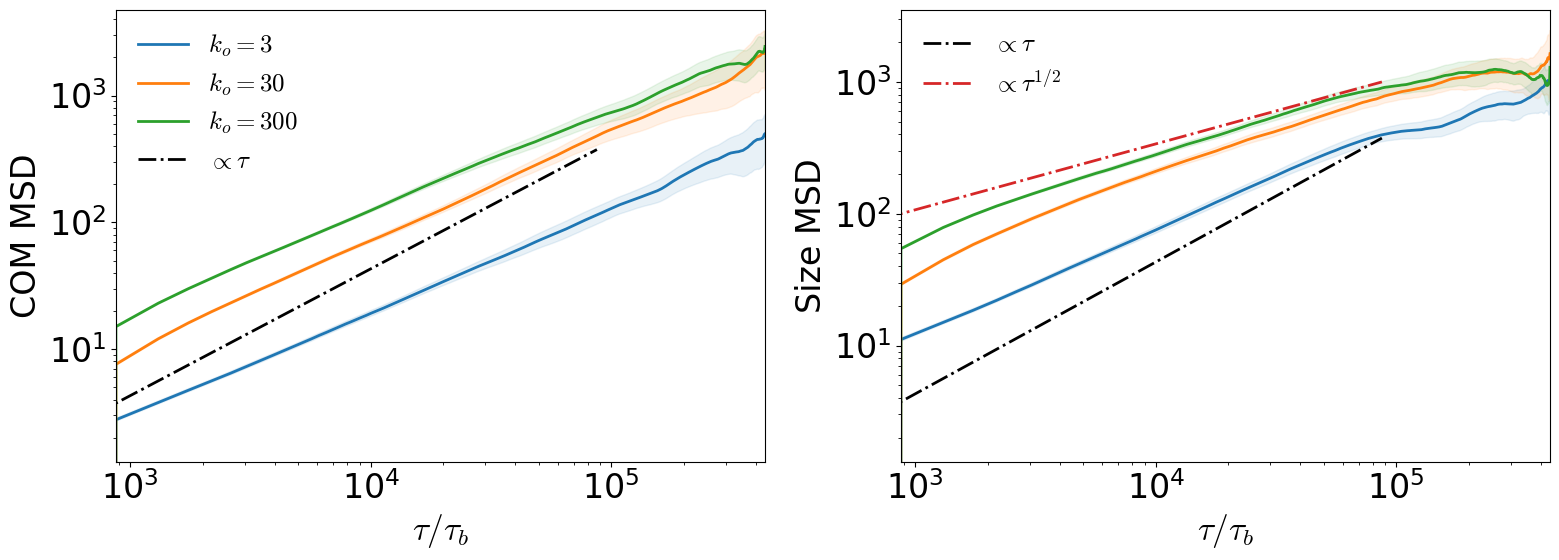

In [81]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))
axarr[0].grid(False)
axarr[1].grid(False)

ko = 30
for h5_path, color in zip(["SFig_single_cluster_msd/single_cluster_ko3_data.h5", 
                            "SFig_single_cluster_msd/single_cluster_ko30_data.h5", 
                            "SFig_single_cluster_msd/single_cluster_ko300_data.h5"], 
                           ('C0', 'C1', 'C2')):
    with h5py.File(h5_path, 'r') as h5_graph:
        msd_length = h5_graph['com_msd'][...].shape[1]
        
        com_msd_list = h5_graph['com_msd'][...]
        len_msd_list = h5_graph['len_msd'][...]

        # Non-dimensionalize time
        avg_time_arr = h5_graph['time'][1:msd_length+1] / diff_time

        std_com_msd = np.std(com_msd_list, axis=0)
        avg_com_msd = np.mean(com_msd_list, axis=0)

        std_len_msd = np.std(len_msd_list, axis=0)
        avg_len_msd = np.mean(len_msd_list, axis=0)

        # Plot COM MSD (left) - normalized by b_diam^2
        plot_confidence_int(axarr[0], avg_time_arr, avg_com_msd, 
                           std_com_msd, num_runs=len(com_msd_list), 
                           color=color, ci=.95, label=f"$k_o = {h5_path.split('_ko')[1].split('_')[0]}$")
        
        # Plot length MSD (right) - normalized by b_diam^2
        plot_confidence_int(axarr[1], avg_time_arr, avg_len_msd, 
                           std_len_msd, num_runs=len(len_msd_list), 
                           color=color, ci=.95, label=None, )

_ = axarr[0].loglog(avg_time_arr[:200], diff_time*avg_time_arr[:200]*ko/8, c='k', linestyle='-.', label=r'$\propto \tau$')
_ = axarr[1].loglog(avg_time_arr[:200], diff_time*avg_time_arr[:200]*ko/8, c='k', linestyle='-.', label=r'$\propto \tau$')
_ = axarr[1].loglog(avg_time_arr[:200], 100*np.power(avg_time_arr[:200]*diff_time, .5), c='tab:red', linestyle='-.', label=r'$\propto \tau^{1/2}$')

# Left subplot - COM MSD
axarr[0].set_ylabel(r"COM MSD")
axarr[0].set_xlabel(r'$\tau/\tau_b$')
axarr[0].set_xlim(1/diff_time, avg_time_arr[-1])
axarr[0].set_xscale('log')
axarr[0].set_yscale('log')
axarr[0].legend(fontsize=18, frameon=False)

# Right subplot - Length MSD
axarr[1].set_ylabel(r"Size MSD")
axarr[1].set_xlabel(r'$\tau/\tau_b$')
axarr[1].set_xlim(1/diff_time, avg_time_arr[-1])
axarr[1].set_xscale('log')
axarr[1].set_yscale('log')
axarr[1].legend(fontsize=18, frameon=False)

fig.tight_layout()
fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_9um.png", dpi=600,bbox_inches='tight')
fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_9um.pdf", dpi=600,bbox_inches='tight')
fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_9um.eps", dpi=600,bbox_inches='tight')
fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_msd_9um.png", dpi=600, bbox_inches="tight")
fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_msd_9um.pdf", dpi=600, bbox_inches="tight")
fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_msd_9um.eps", dpi=600, bbox_inches="tight")

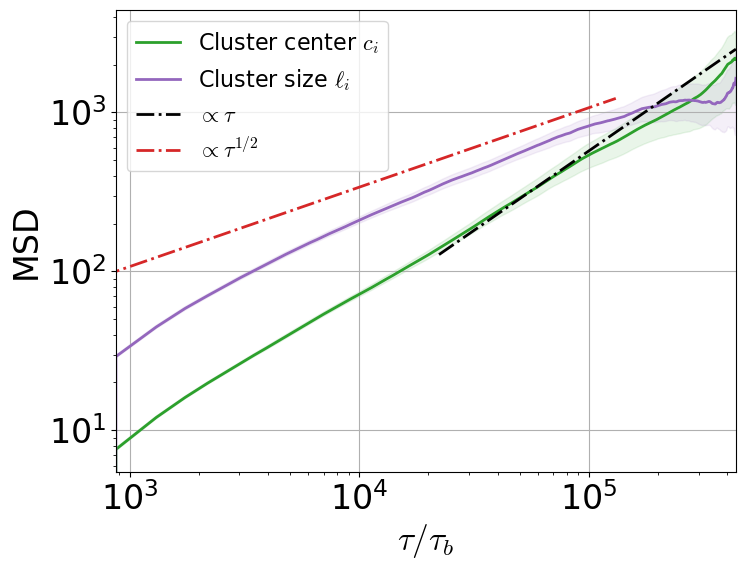

In [73]:
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

ko = 30
# twin_ax = axarr.twinx()
with h5py.File("SFig_single_cluster_msd/single_cluster_ko30_data.h5", 'r') as h5_graph:
    msd_length = h5_graph['com_msd'][...].shape[1]
    
    com_msd_list = h5_graph['com_msd'][...]
    len_msd_list = h5_graph['len_msd'][...]

    # avg_time_arr = time_arr[1:max_length+1]
    avg_time_arr = h5_graph['time'][1:msd_length+1]/diff_time

    # com_msd_list = [com_msd[:max_length] for com_msd in com_msd_arr if len(com_msd) > max_length]
    std_com_msd = np.std(com_msd_list, axis=0)
    avg_com_msd = np.mean(com_msd_list, axis=0)

    # len_msd_list = [len_msd[:max_length] for len_msd in len_msd_arr if len(len_msd) > max_length]
    std_len_msd = np.std(len_msd_list, axis=0)
    avg_len_msd = np.mean(len_msd_list, axis=0)

    plot_confidence_int(axarr, avg_time_arr, avg_com_msd, std_com_msd, num_runs=len(com_msd_list), color='C2', ci=.95, label='Cluster center $c_i$')
    plot_confidence_int(axarr, avg_time_arr, avg_len_msd, std_len_msd, num_runs=len(len_msd_list), color='C4', ci=.95, label='Cluster size $\ell_i$')
    # _ = axarr.loglog(time_arr[1:max_length+1], time_arr[1:max_length+1]*ko, c='k', linestyle='--')
    # _ = axarr.plot(time_arr[1:max_length+1], .25*15*time_arr[1:max_length+1], c='k', linestyle='--')
    # _ = twin_ax.loglog(time_arr[1:max_length+1], 30*time_arr[1:max_length+1], c='k', linestyle='--')

    _ = axarr.set_ylabel(r"MSD")
    # _ = twin_ax.set_ylabel(r"Condensate size MSD [$\mu {\rm m}^2/s$]")
    _ = axarr.set_xlabel(r'$\tau/\tau_b$')
    _ = axarr.set_xlim(1/diff_time,avg_time_arr[-1])

_ = axarr.loglog(avg_time_arr[50:], diff_time * avg_time_arr[50:]*ko/6, c='k', linestyle='-.', label=r'$\propto \tau$')
_ = axarr.loglog(avg_time_arr[:300], 100*np.power(avg_time_arr[:300]*diff_time, .5), c='tab:red', linestyle='-.', label=r'$\propto \tau^{1/2}$')

_ = axarr.legend(fontsize=16)
_ = axarr.set_xscale('log')
_ = axarr.set_yscale('log')

# fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_9um.png", dpi=600,bbox_inches='tight')
# fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_9um.pdf", dpi=600,bbox_inches='tight')
# fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_9um.eps", dpi=600,bbox_inches='tight')
# fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_msd_9um.png", dpi=600, bbox_inches="tight")
# fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_msd_9um.pdf", dpi=600, bbox_inches="tight")
# fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_msd_9um.eps", dpi=600, bbox_inches="tight")


(48, 2301)


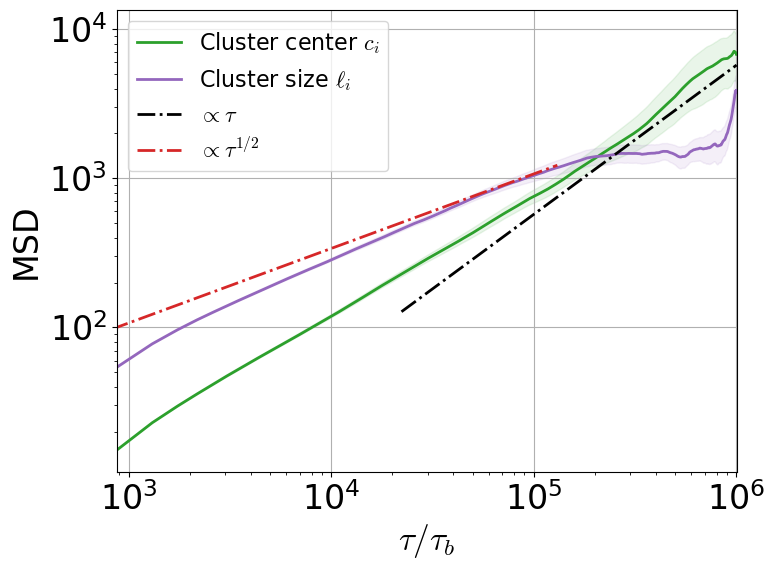

In [14]:
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

ko = 15
# twin_ax = axarr.twinx()
with h5py.File("SFig_single_cluster_msd/single_cluster_ko300_data.h5", 'r') as h5_graph:
    print(h5_graph['com_msd'][...].shape)
    msd_length = h5_graph['com_msd'][...].shape[1]
    
    com_msd_list = h5_graph['com_msd'][...]
    len_msd_list = h5_graph['len_msd'][...]

    # avg_time_arr = time_arr[1:max_length+1]
    avg_time_arr = h5_graph['time'][1:msd_length+1]/diff_time

    # com_msd_list = [com_msd[:max_length] for com_msd in com_msd_arr if len(com_msd) > max_length]
    std_com_msd = np.std(com_msd_list, axis=0)
    avg_com_msd = np.mean(com_msd_list, axis=0)

    # len_msd_list = [len_msd[:max_length] for len_msd in len_msd_arr if len(len_msd) > max_length]
    std_len_msd = np.std(len_msd_list, axis=0)
    avg_len_msd = np.mean(len_msd_list, axis=0)

    plot_confidence_int(axarr, avg_time_arr, avg_com_msd, std_com_msd, num_runs=len(com_msd_list), color='C2', ci=.95, label='Cluster center $c_i$')
    plot_confidence_int(axarr, avg_time_arr, avg_len_msd, std_len_msd, num_runs=len(len_msd_list), color='C4', ci=.95, label='Cluster size $\ell_i$')
    # _ = axarr.loglog(time_arr[1:max_length+1], time_arr[1:max_length+1]*ko, c='k', linestyle='--')
    # _ = axarr.plot(time_arr[1:max_length+1], .25*15*time_arr[1:max_length+1], c='k', linestyle='--')
    # _ = twin_ax.loglog(time_arr[1:max_length+1], 30*time_arr[1:max_length+1], c='k', linestyle='--')

    _ = axarr.set_ylabel(r"MSD")
    # _ = twin_ax.set_ylabel(r"Condensate size MSD [$\mu {\rm m}^2/s$]")
    _ = axarr.set_xlabel(r'$\tau/\tau_b$')
    _ = axarr.set_xlim(1/diff_time, avg_time_arr[-1])

_ = axarr.loglog(avg_time_arr[50:], diff_time*avg_time_arr[50:]*ko/3, c='k', linestyle='-.', label=r'$\propto \tau$')
_ = axarr.loglog(avg_time_arr[:300], 100*np.power(avg_time_arr[:300]*diff_time, .5), c='tab:red', linestyle='-.', label=r'$\propto \tau^{1/2}$')

_ = axarr.legend(fontsize=16)
_ = axarr.set_xscale('log')
_ = axarr.set_yscale('log')


fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_ko300_9um.png", dpi=600,bbox_inches='tight')
fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_ko300_msd_9um.png", dpi=300, bbox_inches="tight")

(48, 600)


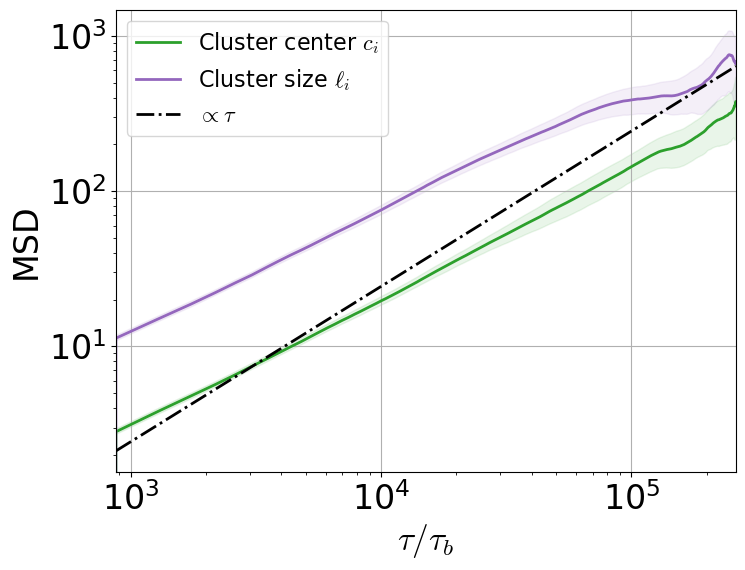

In [37]:
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

ko = 3
# twin_ax = axarr.twinx()
with h5py.File("SFig_single_cluster_msd/single_cluster_ko3_data.h5", 'r') as h5_graph:
    print(h5_graph['com_msd'][...].shape)
    msd_length = h5_graph['com_msd'][...].shape[1]
    
    com_msd_list = h5_graph['com_msd'][...]
    len_msd_list = h5_graph['len_msd'][...]

    # avg_time_arr = time_arr[1:max_length+1]
    avg_time_arr = h5_graph['time'][1:msd_length+1]/diff_time

    # com_msd_list = [com_msd[:max_length] for com_msd in com_msd_arr if len(com_msd) > max_length]
    std_com_msd = np.std(com_msd_list, axis=0)
    avg_com_msd = np.mean(com_msd_list, axis=0)

    # len_msd_list = [len_msd[:max_length] for len_msd in len_msd_arr if len(len_msd) > max_length]
    std_len_msd = np.std(len_msd_list, axis=0)
    avg_len_msd = np.mean(len_msd_list, axis=0)

    plot_confidence_int(axarr, avg_time_arr, avg_com_msd, std_com_msd, num_runs=len(com_msd_list), color='C2', ci=.95, label='Cluster center $c_i$')
    plot_confidence_int(axarr, avg_time_arr, avg_len_msd, std_len_msd, num_runs=len(len_msd_list), color='C4', ci=.95, label='Cluster size $\ell_i$')

    _ = axarr.set_ylabel(r"MSD")
    # _ = twin_ax.set_ylabel(r"Condensate size MSD [$\mu {\rm m}^2/s$]")
    _ = axarr.set_xlabel(r'$\tau/\tau_b$')
    _ = axarr.set_xlim(1/diff_time, avg_time_arr[-1])

_ = axarr.loglog(avg_time_arr[1:], diff_time*avg_time_arr[1:]*ko/np.sqrt(2), c='k', linestyle='-.', label=r'$\propto \tau$')
# _ = axarr.loglog(avg_time_arr[:300], np.power(100*ko*avg_time_arr[:300]*diff_time, .5), c='tab:red', linestyle='-.', label=r'$\propto \tau^{1/2}$')

_ = axarr.legend(fontsize=16)
_ = axarr.set_xscale('log')
_ = axarr.set_yscale('log')


# fig.savefig("SFig_single_cluster_msd/fig_supp_cluster_msd_ko3_9um.png", dpi=600,bbox_inches='tight')
# fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig_supp_cluster_ko3_msd_9um.png", dpi=300, bbox_inches="tight")

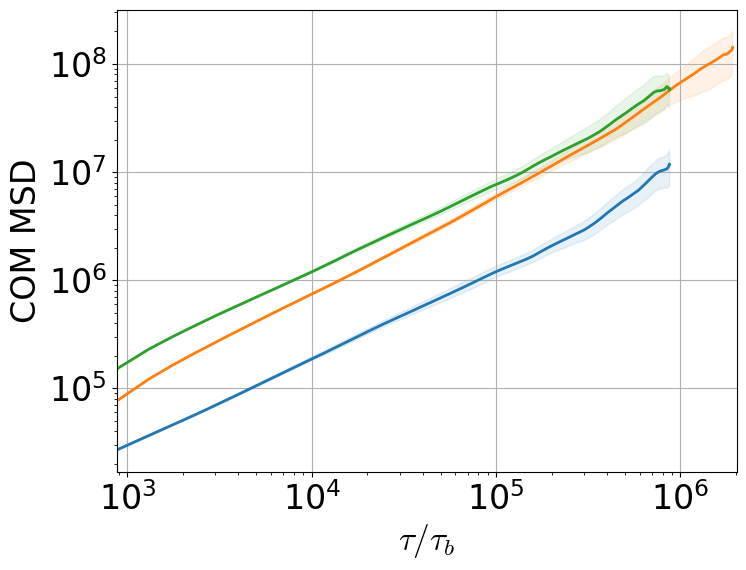

In [ ]:
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

ko = 15
# twin_ax = axarr.twinx()
for h5_path, color in zip(["SFig_single_cluster_msd/single_cluster_ko3_data.h5", "SFig_single_cluster_msd/single_cluster_ko30_data.h5", "SFig_single_cluster_msd/single_cluster_ko300_data.h5"], ('C0', 'C1', 'C2')):
    with h5py.File(h5_path, 'r') as h5_graph:
        len_msd_list = h5_graph['len_msd'][...]
        msd_length = h5_graph['com_msd'][...].shape[1]
        
        com_msd_list = h5_graph['com_msd'][...]
        len_msd_list = h5_graph['len_msd'][...]

        # avg_time_arr = time_arr[1:max_length+1]
        avg_time_arr = h5_graph['time'][1:msd_length+1]

        # com_msd_list = [com_msd[:max_length] for com_msd in com_msd_arr if len(com_msd) > max_length]
        std_com_msd = np.std(com_msd_list, axis=0)
        avg_com_msd = np.mean(com_msd_list, axis=0)

        # len_msd_list = [len_msd[:max_length] for len_msd in len_msd_arr if len(len_msd) > max_length]
        std_len_msd = np.std(len_msd_list, axis=0)
        avg_len_msd = np.mean(len_msd_list, axis=0)

        plot_confidence_int(axarr, avg_time_arr/diff_time, avg_com_msd/(b_diam**2), std_com_msd/(b_diam**2), num_runs=len(com_msd_list), color=color, ci=.95, label='Cluster center $c_i$')

_ = axarr.set_ylabel(r"COM MSD")
# _ = twin_ax.set_ylabel(r"Condensate size MSD [$\mu {\rm m}^2/s$]")
_ = axarr.set_xlabel(r'$\tau/\tau_b$')

_ = axarr.set_xlim(1/diff_time, avg_time_arr[-1]/diff_time)

# _ = axarr.loglog(avg_time_arr[50:], avg_time_arr[50:]*ko/3, c='k', linestyle='-.', label=r'$\propto \tau$')
# _ = axarr.loglog(avg_time_arr[:300], 100*np.power(avg_time_arr[:300], .5), c='tab:red', linestyle='-.', label=r'$\propto \tau^{1/2}$')

# _ = axarr.legend(fontsize=16)
_ = axarr.set_xscale('log')
_ = axarr.set_yscale('log')



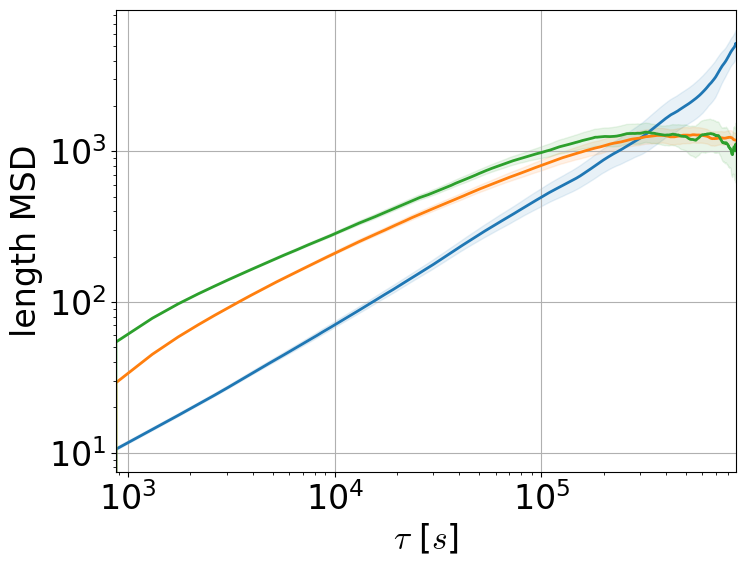

In [47]:
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

ko = 15
# twin_ax = axarr.twinx()
for h5_path, color in zip(["SFig_single_cluster_msd/single_cluster_ko3_data.h5", "SFig_single_cluster_msd/single_cluster_ko30_data.h5", "SFig_single_cluster_msd/single_cluster_ko300_data.h5"], ('C0', 'C1', 'C2')):
    with h5py.File(h5_path, 'r') as h5_graph:
        len_msd_list = h5_graph['len_msd'][...]
        msd_length = h5_graph['com_msd'][...].shape[1]
        
        com_msd_list = h5_graph['com_msd'][...]
        len_msd_list = h5_graph['len_msd'][...]

        # avg_time_arr = time_arr[1:max_length+1]
        avg_time_arr = h5_graph['time'][1:msd_length+1]
        avg_time_arr = avg_time_arr/diff_time

        # com_msd_list = [com_msd[:max_length] for com_msd in com_msd_arr if len(com_msd) > max_length]
        std_com_msd = np.std(com_msd_list, axis=0)
        avg_com_msd = np.mean(com_msd_list, axis=0)

        # len_msd_list = [len_msd[:max_length] for len_msd in len_msd_arr if len(len_msd) > max_length]
        std_len_msd = np.std(len_msd_list, axis=0)
        avg_len_msd = np.mean(len_msd_list, axis=0)

        # plot_confidence_int(axarr, avg_time_arr, avg_com_msd, std_com_msd, num_runs=len(com_msd_list), color=color, ci=.95, label='Cluster center $c_i$')
        plot_confidence_int(axarr, avg_time_arr, avg_len_msd, std_len_msd, num_runs=len(len_msd_list), color=color, ci=.95, label='Cluster size $\ell_i$')
        # _ = axarr.loglog(time_arr[1:max_length+1], time_arr[1:max_length+1]*ko, c='k', linestyle='--')
        # _ = axarr.plot(time_arr[1:max_length+1], .25*15*time_arr[1:max_length+1], c='k', linestyle='--')
        # _ = twin_ax.loglog(time_arr[1:max_length+1], 30*time_arr[1:max_length+1], c='k', linestyle='--')

_ = axarr.set_ylabel(r"length MSD")
# _ = twin_ax.set_ylabel(r"Condensate size MSD [$\mu {\rm m}^2/s$]")
_ = axarr.set_xlabel(r'$\tau$ [$s$]')

_ = axarr.set_xlim(1/diff_time,avg_time_arr[-1])

# _ = axarr.loglog(avg_time_arr[50:], avg_time_arr[50:]*ko/3, c='k', linestyle='-.', label=r'$\propto \tau$')
# _ = axarr.loglog(avg_time_arr[:300], 100*np.power(avg_time_arr[:300], .5), c='tab:red', linestyle='-.', label=r'$\propto \tau^{1/2}$')

# _ = axarr.legend(fontsize=16)
_ = axarr.set_xscale('log')
_ = axarr.set_yscale('log')


# fig.savefig("Figure6/supp_cluster_msd_ko3_9um.png", dpi=600,bbox_inches='tight')
# fig.savefig("/mnt/home/alamson/papers/dyn_cond_paper/images/fig5_supp_cluster_msd_ko3_9um.png", dpi=300, bbox_inches="tight")

# Collect data

Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees


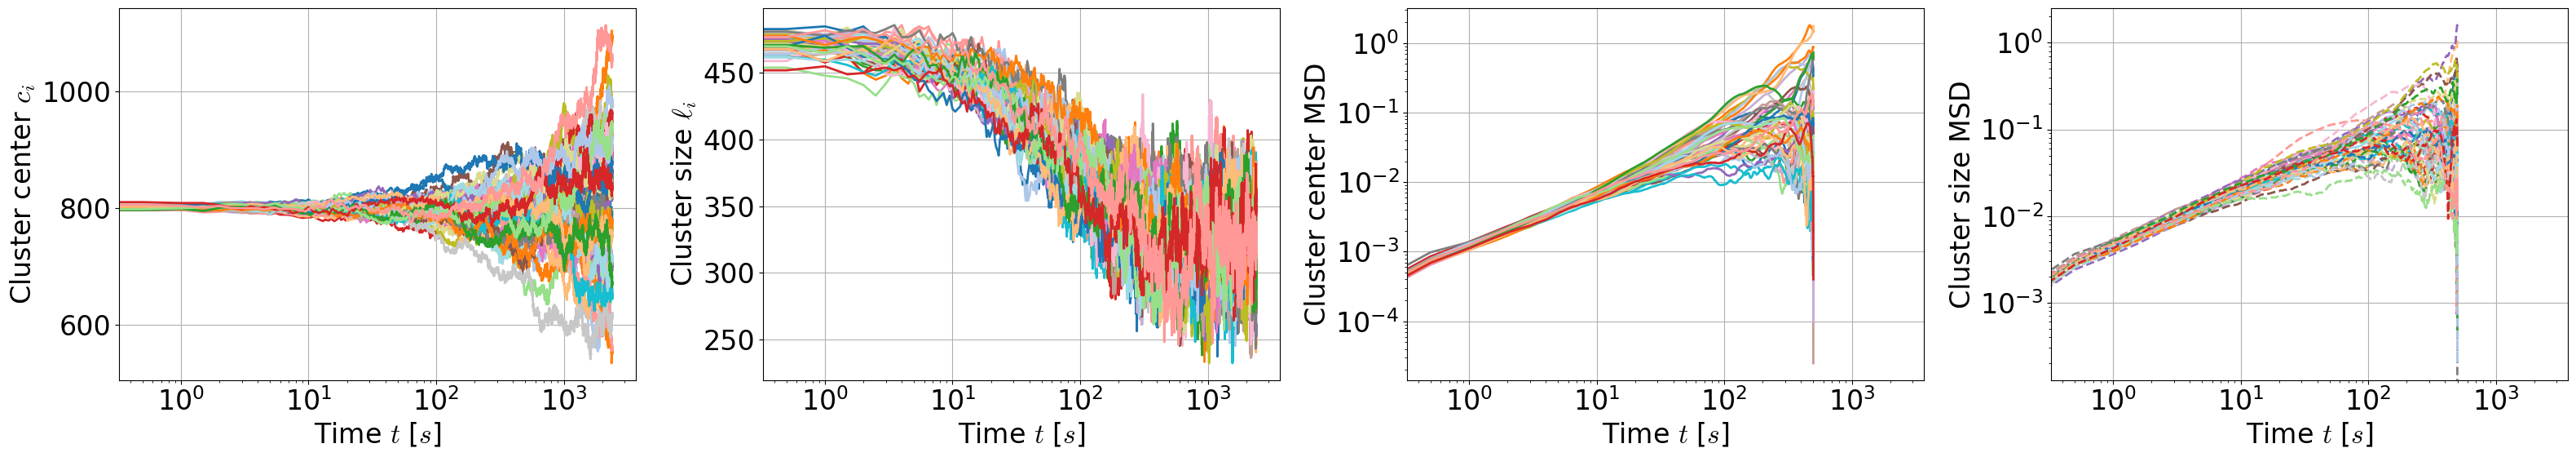

In [49]:
data_path = ceph_path / "DynCondPaper/24-05-02_aLc1_scan.48_line1600_Pin9um_2xKe30_ks100_1patch"
h5_list = list(data_path.glob('simulations/*/analysis/cluster_analysis.h5'))
large_tree_length = 100

tableau20_colors = iter(cycle(plt.cm.tab20.colors))
fig, axarr = plt.subplots(1,4, figsize=(32, 6), sharex=True)


com_msd_arr = []
len_msd_arr = []
com_arr_list = []
len_arr_list = []
for h5_cluster_file in h5_list:
    with h5py.File(h5_cluster_file, 'r') as h5_data:
        cluster_grp = h5_data['clusters']
        time_arr = h5_data['time'][...]
        time_grp_list = sorted(cluster_grp.values(), key=lambda x: x.attrs['time'])
        clusters = []
        for tg in time_grp_list:
            clusters += [[cla.Cluster(h5_data = c) for c in tg.values()]]

    # Cluster tree
    root_clusters = cla.find_descendants(clusters, thresh=cluster_similarity_threshold, nskip=nskip)

    trees = []
    tree_id_gen = aa.helpers.gen_id()
    for root in root_clusters:
        tree = cla.ClusterTree(next(tree_id_gen))
        tree.add_recursive(root)
        trees += [tree]
    
    # Prune small trees
    trees = [tree for tree in trees if len(tree.clusters) > large_tree_length]

    print(f"Found {len(trees)} trees")
    if len(trees) != 1:
        print("Found multiple trees")
        continue


    # Graph all clusters
    for tree, color in zip(trees, tableau20_colors):
        clust_len_arr = []
        clust_com_arr = []
        time_arr = []
        # if len(tree.clusters) < large_tree_length:
        #     continue
        for clust in tree.clusters:
            clust_len_arr += [len(clust.part_ids)]
            clust_com_arr += [np.mean(clust.part_ids)]
            time_arr += [clust.time]
        
        # Sort arrays by time
        sort_indices = np.argsort(time_arr)
        clust_len_arr = np.array(clust_len_arr, dtype=float)[sort_indices]
        clust_com_arr = np.array(clust_com_arr)[sort_indices]
        time_arr = np.array(time_arr)[sort_indices]

        # Combine clusters with the same time
        unique_time, indices = np.unique(time_arr, return_inverse=True)

        # Initialize new arrays
        new_clust_len_arr = np.zeros(len(unique_time))
        new_clust_com_arr = np.zeros(len(unique_time))

        # Iterate over unique values
        for i, new_ind in enumerate(indices):
            new_clust_len_arr[new_ind] += clust_len_arr[i]
            new_clust_com_arr[new_ind] += clust_com_arr[i]*clust_len_arr[i]
        new_clust_com_arr /= new_clust_len_arr

        _ = axarr[0].plot(unique_time, new_clust_com_arr, c=color)
        _ = axarr[1].plot(unique_time, new_clust_len_arr, c=color)

        time_arr = unique_time
        clust_len_arr = new_clust_len_arr
        clust_com_arr = new_clust_com_arr

        com_msd = cluster_msd(clust_com_arr[start_index:])
        _ = axarr[2].plot(time_arr[:-start_index], com_msd*.01*.01, c=color)

        com_msd_arr.append(com_msd)
        com_arr_list.append(clust_com_arr)

        len_msd = cluster_msd(clust_len_arr[start_index:])
        _ = axarr[3].plot(time_arr[:-start_index], len_msd*.01*.01, c=color, linestyle='--')


        len_msd_arr.append(len_msd)
        len_arr_list.append(clust_len_arr)
    
_ = axarr[0].set_ylabel('Cluster center $c_i$')
_ = axarr[1].set_ylabel('Cluster size $\ell_i$')
_ = axarr[2].set_ylabel('Cluster center MSD')
_ = axarr[3].set_ylabel('Cluster size MSD')
for ax in axarr:
    _ = ax.set_xlabel('Time $t$ [$s$]')
_ = axarr[2].set_xscale('log')
_ = axarr[2].set_yscale('log')
_ = axarr[3].set_yscale('log')

fig.tight_layout()


In [50]:
# np.array(com_msd_arr).shape
# max_length = 2400-start_index 
msd_length = min([len(arr) for arr in com_msd_arr])
print(msd_length)
com_msd_list =[com_msd[:msd_length] for com_msd in com_msd_arr if len(com_msd) >= msd_length]
len_msd_list = [len_msd[:msd_length] for len_msd in len_msd_arr if len(len_msd) >= msd_length]
com_list =[com[:msd_length] for com in com_arr_list if len(com) >= msd_length]
len_list = [leng[:msd_length] for leng in len_arr_list if len(leng) >= msd_length]

with h5py.File("SFig_single_cluster_msd/single_cluster_ko30_data.h5", 'w') as h5_graph:
    h5_graph.attrs['data_dir'] = '24-05-02_aLc1_scan.48_line1600_Pin9um_2xKe30_ks100_1patch'
    h5_graph.attrs['start_ind'] = start_index
    time_dset = h5_graph.create_dataset('time', data=np.array(time_arr))
    com_msd_dset = h5_graph.create_dataset('com_msd', data=np.array(com_msd_list))
    len_msd_dset = h5_graph.create_dataset('len_msd', data=np.array(len_msd_list))
    com_arr_dset = h5_graph.create_dataset('com', data=np.array(com_list))
    len_arr_dset = h5_graph.create_dataset('len', data=np.array(len_list))




1000


Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees


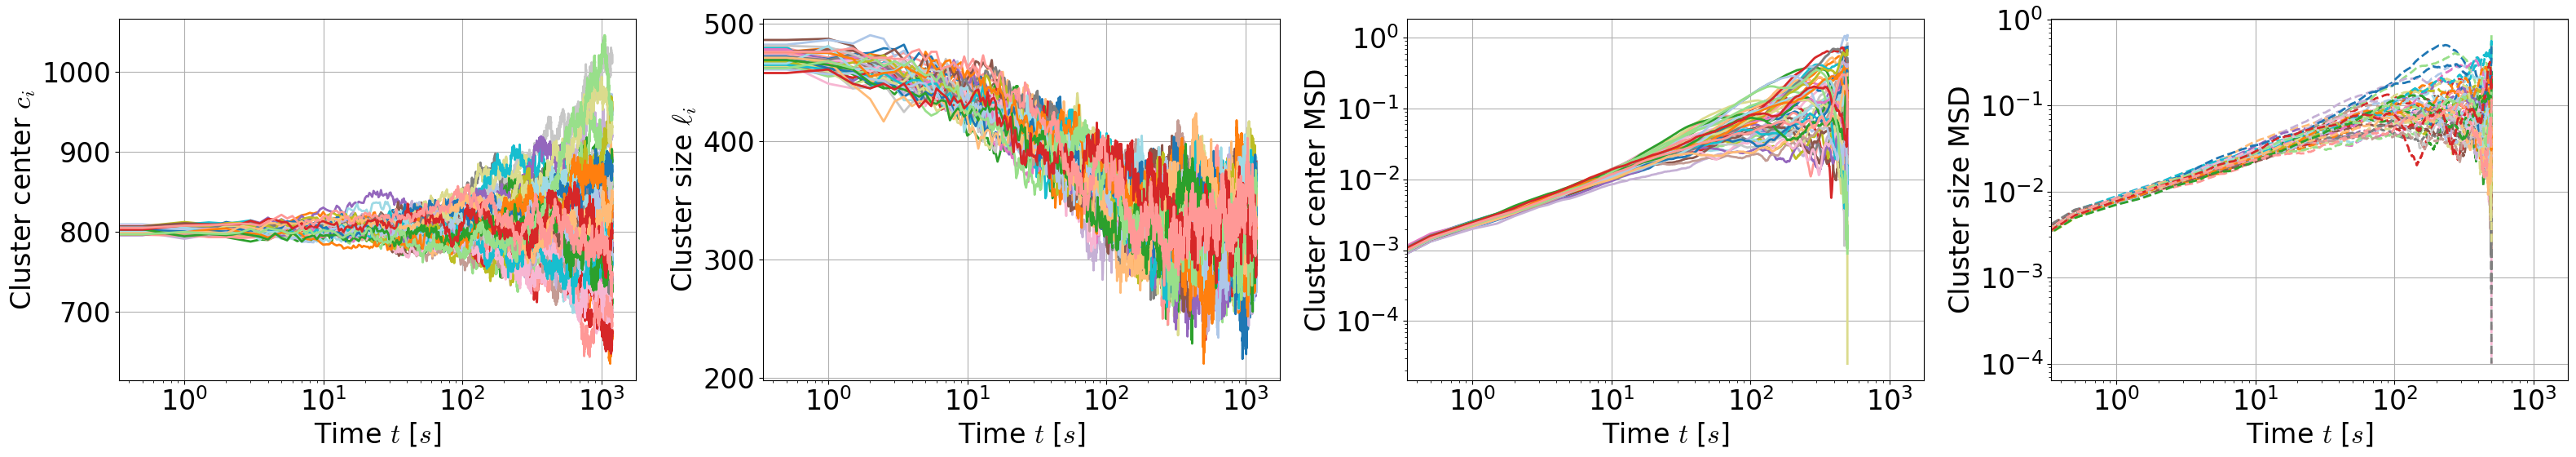

In [51]:
data_path = ceph_path / "DynCondPaper/24-09-20_aLc1_scan.48_line1600_Pin9um_2xKe30_ks100_ko300_1patch"
h5_list = list(data_path.glob('simulations/*/analysis/cluster_analysis.h5'))
large_tree_length = 100

tableau20_colors = iter(cycle(plt.cm.tab20.colors))
fig, axarr = plt.subplots(1,4, figsize=(32, 6), sharex=True)


com_msd_arr = []
len_msd_arr = []
com_arr_list = []
len_arr_list = []
for h5_cluster_file in h5_list:
    with h5py.File(h5_cluster_file, 'r') as h5_data:
        cluster_grp = h5_data['clusters']
        time_arr = h5_data['time'][...]
        time_grp_list = sorted(cluster_grp.values(), key=lambda x: x.attrs['time'])
        clusters = []
        for tg in time_grp_list:
            clusters += [[cla.Cluster(h5_data = c) for c in tg.values()]]

    # Cluster tree
    root_clusters = cla.find_descendants(clusters, thresh=cluster_similarity_threshold, nskip=nskip)

    trees = []
    tree_id_gen = aa.helpers.gen_id()
    for root in root_clusters:
        tree = cla.ClusterTree(next(tree_id_gen))
        tree.add_recursive(root)
        trees += [tree]
    
    # Prune small trees
    trees = [tree for tree in trees if len(tree.clusters) > large_tree_length]

    print(f"Found {len(trees)} trees")
    if len(trees) != 1:
        print("Found multiple trees")
        continue


    # Graph all clusters
    for tree, color in zip(trees, tableau20_colors):
        clust_len_arr = []
        clust_com_arr = []
        time_arr = []
        # if len(tree.clusters) < large_tree_length:
        #     continue
        for clust in tree.clusters:
            clust_len_arr += [len(clust.part_ids)]
            clust_com_arr += [np.mean(clust.part_ids)]
            time_arr += [clust.time]
        
        # Sort arrays by time
        sort_indices = np.argsort(time_arr)
        clust_len_arr = np.array(clust_len_arr, dtype=float)[sort_indices]
        clust_com_arr = np.array(clust_com_arr)[sort_indices]
        time_arr = np.array(time_arr)[sort_indices]

        # Combine clusters with the same time
        unique_time, indices = np.unique(time_arr, return_inverse=True)

        # Initialize new arrays
        new_clust_len_arr = np.zeros(len(unique_time))
        new_clust_com_arr = np.zeros(len(unique_time))

        # Iterate over unique values
        for i, new_ind in enumerate(indices):
            new_clust_len_arr[new_ind] += clust_len_arr[i]
            new_clust_com_arr[new_ind] += clust_com_arr[i]*clust_len_arr[i]
        new_clust_com_arr /= new_clust_len_arr

        _ = axarr[0].plot(unique_time, new_clust_com_arr, c=color)
        _ = axarr[1].plot(unique_time, new_clust_len_arr, c=color)

        time_arr = unique_time
        clust_len_arr = new_clust_len_arr
        clust_com_arr = new_clust_com_arr

        com_msd = cluster_msd(clust_com_arr[start_index:])
        _ = axarr[2].plot(time_arr[:-start_index], com_msd*.01*.01, c=color)

        com_msd_arr.append(com_msd)
        com_arr_list.append(clust_com_arr)

        len_msd = cluster_msd(clust_len_arr[start_index:])
        _ = axarr[3].plot(time_arr[:-start_index], len_msd*.01*.01, c=color, linestyle='--')


        len_msd_arr.append(len_msd)
        len_arr_list.append(clust_len_arr)
    
_ = axarr[0].set_ylabel('Cluster center $c_i$')
_ = axarr[1].set_ylabel('Cluster size $\ell_i$')
_ = axarr[2].set_ylabel('Cluster center MSD')
_ = axarr[3].set_ylabel('Cluster size MSD')
for ax in axarr:
    _ = ax.set_xlabel('Time $t$ [$s$]')
_ = axarr[2].set_xscale('log')
_ = axarr[2].set_yscale('log')
_ = axarr[3].set_yscale('log')

fig.tight_layout()


In [52]:
# np.array(com_msd_arr).shape
# max_length = 2400-start_index 
msd_length = min([len(arr) for arr in com_msd_arr])
print(msd_length)
com_msd_list =[com_msd[:msd_length] for com_msd in com_msd_arr if len(com_msd) >= msd_length]
len_msd_list = [len_msd[:msd_length] for len_msd in len_msd_arr if len(len_msd) >= msd_length]
com_list =[com[:msd_length] for com in com_arr_list if len(com) >= msd_length]
len_list = [leng[:msd_length] for leng in len_arr_list if len(leng) >= msd_length]

with h5py.File("SFig_single_cluster_msd/single_cluster_ko300_data.h5", 'w') as h5_graph:
    h5_graph.attrs['data_dir'] = '24-09-20_aLc1_scan.48_line1600_Pin9um_2xKe30_ks100_ko300_1patch'
    h5_graph.attrs['start_ind'] = start_index
    time_dset = h5_graph.create_dataset('time', data=np.array(time_arr))
    com_msd_dset = h5_graph.create_dataset('com_msd', data=np.array(com_msd_list))
    len_msd_dset = h5_graph.create_dataset('len_msd', data=np.array(len_msd_list))
    com_arr_dset = h5_graph.create_dataset('com', data=np.array(com_list))
    len_arr_dset = h5_graph.create_dataset('len', data=np.array(len_list))




1000


Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees
Found 1 trees


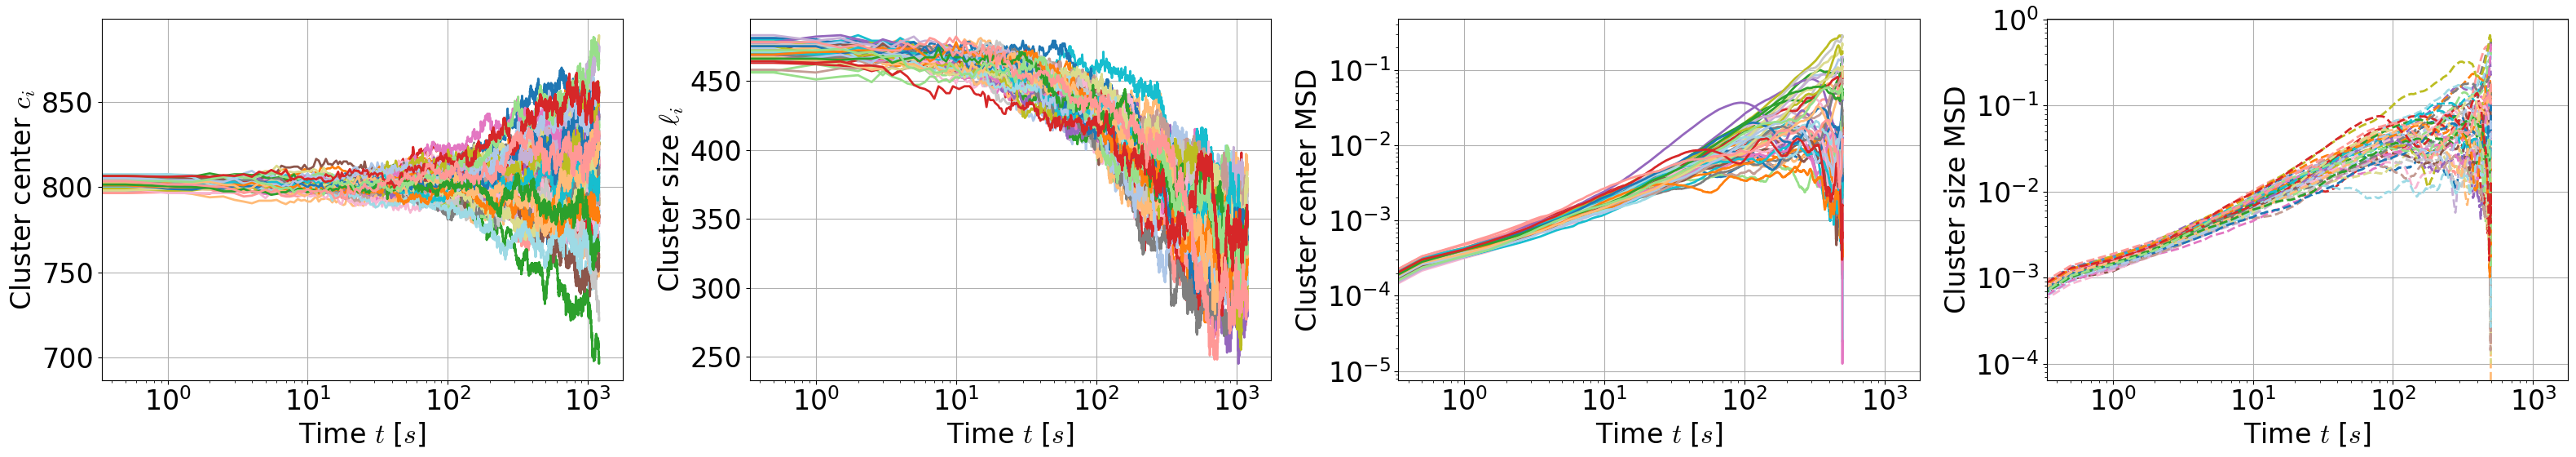

In [53]:
data_path = ceph_path / "DynCondPaper/24-09-20_aLc1_scan.48_line1600_Pin9um_2xKe30_ks100_ko3_1patch"
h5_list = list(data_path.glob('simulations/*/analysis/cluster_analysis.h5'))
large_tree_length = 100

tableau20_colors = iter(cycle(plt.cm.tab20.colors))
fig, axarr = plt.subplots(1,4, figsize=(32, 6), sharex=True)


com_msd_arr = []
len_msd_arr = []
com_arr_list = []
len_arr_list = []
for h5_cluster_file in h5_list:
    with h5py.File(h5_cluster_file, 'r') as h5_data:
        cluster_grp = h5_data['clusters']
        time_arr = h5_data['time'][...]
        time_grp_list = sorted(cluster_grp.values(), key=lambda x: x.attrs['time'])
        clusters = []
        for tg in time_grp_list:
            clusters += [[cla.Cluster(h5_data = c) for c in tg.values()]]

    # Cluster tree
    root_clusters = cla.find_descendants(clusters, thresh=cluster_similarity_threshold, nskip=nskip)

    trees = []
    tree_id_gen = aa.helpers.gen_id()
    for root in root_clusters:
        tree = cla.ClusterTree(next(tree_id_gen))
        tree.add_recursive(root)
        trees += [tree]
    
    # Prune small trees
    trees = [tree for tree in trees if len(tree.clusters) > large_tree_length]

    print(f"Found {len(trees)} trees")
    if len(trees) != 1:
        print("Found multiple trees")
        continue


    # Graph all clusters
    for tree, color in zip(trees, tableau20_colors):
        clust_len_arr = []
        clust_com_arr = []
        time_arr = []
        # if len(tree.clusters) < large_tree_length:
        #     continue
        for clust in tree.clusters:
            clust_len_arr += [len(clust.part_ids)]
            clust_com_arr += [np.mean(clust.part_ids)]
            time_arr += [clust.time]
        
        # Sort arrays by time
        sort_indices = np.argsort(time_arr)
        clust_len_arr = np.array(clust_len_arr, dtype=float)[sort_indices]
        clust_com_arr = np.array(clust_com_arr)[sort_indices]
        time_arr = np.array(time_arr)[sort_indices]

        # Combine clusters with the same time
        unique_time, indices = np.unique(time_arr, return_inverse=True)

        # Initialize new arrays
        new_clust_len_arr = np.zeros(len(unique_time))
        new_clust_com_arr = np.zeros(len(unique_time))

        # Iterate over unique values
        for i, new_ind in enumerate(indices):
            new_clust_len_arr[new_ind] += clust_len_arr[i]
            new_clust_com_arr[new_ind] += clust_com_arr[i]*clust_len_arr[i]
        new_clust_com_arr /= new_clust_len_arr

        _ = axarr[0].plot(unique_time, new_clust_com_arr, c=color)
        _ = axarr[1].plot(unique_time, new_clust_len_arr, c=color)

        time_arr = unique_time
        clust_len_arr = new_clust_len_arr
        clust_com_arr = new_clust_com_arr
        

        com_msd = cluster_msd(clust_com_arr[start_index:])
        _ = axarr[2].plot(time_arr[:-start_index], com_msd*.01*.01, c=color)

        com_msd_arr.append(com_msd)
        com_arr_list.append(clust_com_arr)

        len_msd = cluster_msd(clust_len_arr[start_index:])
        _ = axarr[3].plot(time_arr[:-start_index], len_msd*.01*.01, c=color, linestyle='--')


        len_msd_arr.append(len_msd)
        len_arr_list.append(clust_len_arr)
    
_ = axarr[0].set_ylabel('Cluster center $c_i$')
_ = axarr[1].set_ylabel('Cluster size $\ell_i$')
_ = axarr[2].set_ylabel('Cluster center MSD')
_ = axarr[3].set_ylabel('Cluster size MSD')
for ax in axarr:
    _ = ax.set_xlabel('Time $t$ [$s$]')
_ = axarr[2].set_xscale('log')
_ = axarr[2].set_yscale('log')
_ = axarr[3].set_yscale('log')

fig.tight_layout()

In [54]:
# np.array(com_msd_arr).shape
# max_length = 2400-start_index 
msd_length = min([len(arr) for arr in com_msd_arr])
print(msd_length)
com_msd_list =[com_msd[:msd_length] for com_msd in com_msd_arr if len(com_msd) >= msd_length]
len_msd_list = [len_msd[:msd_length] for len_msd in len_msd_arr if len(len_msd) >= msd_length]
com_list =[com[:msd_length] for com in com_arr_list if len(com) >= msd_length]
len_list = [leng[:msd_length] for leng in len_arr_list if len(leng) >= msd_length]

with h5py.File("SFig_single_cluster_msd/single_cluster_ko3_data.h5", 'w') as h5_graph:
    h5_graph.attrs['data_dir'] = '24-09-20_aLc1_scan.48_line1600_Pin9um_2xKe30_ks100_ko3_1patch'
    h5_graph.attrs['start_ind'] = start_index
    time_dset = h5_graph.create_dataset('time', data=np.array(time_arr))
    com_msd_dset = h5_graph.create_dataset('com_msd', data=np.array(com_msd_list))
    len_msd_dset = h5_graph.create_dataset('len_msd', data=np.array(len_msd_list))
    com_arr_dset = h5_graph.create_dataset('com', data=np.array(com_list))
    len_arr_dset = h5_graph.create_dataset('len', data=np.array(len_list))




1000
